In [1]:
import os
import random
import time
from pathlib import Path
from tqdm import tqdm
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.randn(10000, 10000, device=device)
print("Computation successful on", device)


Using device: cuda
Computation successful on cuda


In [3]:
# CONFIGURATION

data_root = Path(r"C:/Users/Jimmy/OneDrive/Desktop/test/DS6050_Ai_Detection")  # adjust as needed
train_dir = data_root / "train"
val_dir = data_root / "validation"

batch_size = 32
num_workers = 4
num_epochs = 5
learning_rate = 1e-4
train_percent = 0.5  # train/validate on 50% of data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# DATA TRANSFORMS

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize for ResNet
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [5]:
# dataloader loads alphabetically, so we need to swap labels
class CustomImageFolder(datasets.ImageFolder):
    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        # Swap label: make 'real' = 0, 'fake' = 1
        label = 1 - label
        return img, label

In [6]:
# LOAD DATASETS

train_dataset = CustomImageFolder(root=str(train_dir), transform=transform)
val_dataset = CustomImageFolder(root=str(val_dir), transform=transform)

print("Original class mapping:", train_dataset.class_to_idx)  # still 'fake':0, 'real':1

# --- SUBSET FUNCTION ---
def subset_dataset(dataset, percent):
    if percent >= 1.0:
        return dataset
    subset_size = int(len(dataset) * percent)
    indices = random.sample(range(len(dataset)), subset_size)
    return Subset(dataset, indices)

train_dataset = subset_dataset(train_dataset, train_percent)
val_dataset = subset_dataset(val_dataset, train_percent)

# --- DATALOADERS ---
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Training on {len(train_dataset)} images, validating on {len(val_dataset)} images.")

Original class mapping: {'fake': 0, 'real': 1}
Training on 57600 images, validating on 14170 images.


In [7]:
subset = train_dataset  # your Subset object

# sample first 10 indices from the subset
for idx in range(10):
    actual_idx = subset.indices[idx]  # map to original dataset
    img, label = subset[idx]
    path = subset.dataset.imgs[actual_idx][0]  # original file path
    print(f"{path} --> Label: {label}")

C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\097831.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\0036557.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\0073054.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\095032.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\114956.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\000000010449.jpg --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\0045719.png --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\fake\069498.png --> Label: 1
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\000000541440.jpg --> Label: 0
C:\Users\Jimmy\OneDrive\Desktop\test\DS6050_Ai_Detection\train\real\0060073.png --> Label: 0


In [8]:
# MODEL SETUP (ResNet50)

model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # binary classification (real vs fake)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

c:\Users\Jimmy\miniconda3\envs\id_ai\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Jimmy\miniconda3\envs\id_ai\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


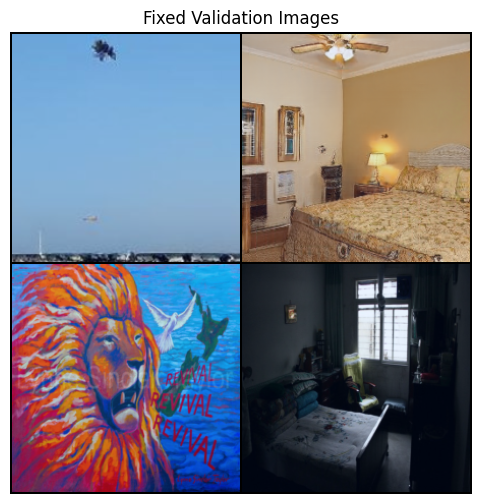

Fake: 025483.png
Fake: 020559.png
Real: 0001705.png
Real: 000000464358.jpg


In [9]:

# SEED = 42
# torch.manual_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)

grid_size = 2  # 2x2 grid
num_images = grid_size * grid_size

# Get all paths and labels
all_paths = [p for p, l in val_dataset.dataset.samples] if isinstance(val_dataset, torch.utils.data.Subset) else [p for p, l in val_dataset.samples]
all_labels = [l for p, l in val_dataset.dataset.samples] if isinstance(val_dataset, torch.utils.data.Subset) else [l for p, l in val_dataset.samples]

labels_tensor = torch.tensor(all_labels)

# Split real and fake indices
real_indices = (labels_tensor == 0).nonzero(as_tuple=True)[0]
fake_indices = (labels_tensor == 1).nonzero(as_tuple=True)[0]

# Take half from each class
half_num = num_images // 2
real_sample = real_indices[torch.randperm(len(real_indices))[:half_num]]
fake_sample = fake_indices[torch.randperm(len(fake_indices))[:half_num]]

subset_indices = torch.cat([real_sample, fake_sample])

# Load images and labels
fixed_images = torch.stack([val_dataset.dataset[i][0] for i in subset_indices]).to(device)
fixed_labels = torch.tensor([val_dataset.dataset[i][1] for i in subset_indices]).to(device)
fixed_paths = [all_paths[i] for i in subset_indices]

# Visualize
grid_img = make_grid(fixed_images.cpu(), nrow=grid_size, normalize=True)
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid_img.numpy(), (1,2,0)))
plt.axis("off")
plt.title("Fixed Validation Images")
plt.show()

for path, lbl in zip(fixed_paths, fixed_labels):
    print(f"{'Real' if lbl==0 else 'Fake'}: {os.path.basename(path)}")

In [10]:
# Training loop

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    best_val_acc = 0.0
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        print(f"\n🔹 Epoch {epoch+1}/{num_epochs}")

        # Wrap train loader with tqdm
        train_pbar = tqdm(train_loader, desc="Training", unit="batch")
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            train_acc = 100 * correct / total
            avg_loss = running_loss / (len(train_loader) if len(train_loader) > 0 else 1)

            # Live update progress bar
            train_pbar.set_postfix({
                "Loss": f"{avg_loss:.4f}",
                "Train Acc": f"{train_acc:.2f}%"
            })

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_pbar = tqdm(val_loader, desc="Validating", unit="batch", leave=False)
        with torch.no_grad():
            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

            #-------------images
            outputs_grid = model(fixed_images)
            preds_grid = torch.argmax(outputs_grid, dim=1)

        val_acc = 100 * val_correct / val_total

        label_names = ['Real', 'Fake']
        true_names = [label_names[l.item()] for l in fixed_labels]
        pred_names = [label_names[p.item()] for p in preds_grid]

        # Create the figure
        fig, axs = plt.subplots(3, 1, figsize=(8, 8))

        # --- Row 1: Image grid ---
        grid_img = make_grid(fixed_images.cpu(), nrow=grid_size, normalize=True)
        axs[0].imshow(np.transpose(grid_img.numpy(), (1, 2, 0)))
        axs[0].set_title("Validation Samples")
        axs[0].axis("off")

        # Image dimensions for positioning labels
        img_w = grid_img.shape[2] // grid_size
        img_h = grid_img.shape[1] // grid_size

        # --- Row 2: True labels (white background + text) ---
        axs[1].imshow(np.ones((img_h * grid_size, img_w * grid_size, 3)))
        axs[1].set_title("True Labels")
        axs[1].axis("off")
        for i, lbl in enumerate(true_names):
            axs[1].text(
                (i % grid_size + 0.5) * img_w,
                (i // grid_size + 0.5) * img_h,
                lbl,
                ha='center', va='center', fontsize=14, color='black'
            )

        # --- Row 3: Predicted labels (green/red text for correctness) ---
        axs[2].imshow(np.ones((img_h * grid_size, img_w * grid_size, 3)))
        axs[2].set_title("Predicted Labels")
        axs[2].axis("off")
        for i, lbl in enumerate(pred_names):
            color = 'green' if lbl == true_names[i] else 'red'
            axs[2].text(
                (i % grid_size + 0.5) * img_w,
                (i // grid_size + 0.5) * img_h,
                lbl,
                ha='center', va='center', fontsize=14, color=color
            )

        plt.tight_layout()
        plt.show()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_resnet50_baseline.pth")

        print(f"Epoch {epoch+1}/{num_epochs} "
              f"Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    print(f"\nTraining complete in {(time.time() - start_time)/60:.2f} minutes.")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")


🔹 Epoch 1/5


Training: 100%|██████████| 1800/1800 [11:09<00:00,  2.69batch/s, Loss=0.2750, Train Acc=88.58%]


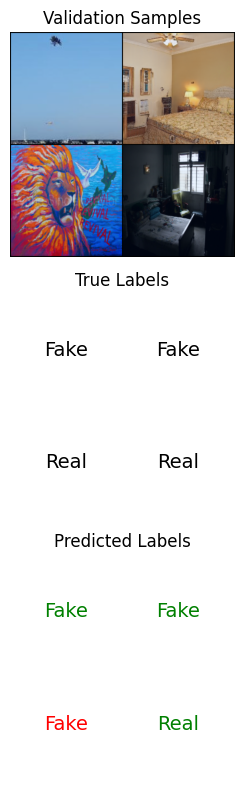

Epoch 1/5 Loss: 0.2750 | Train Acc: 88.58% | Val Acc: 90.47%

🔹 Epoch 2/5


Training: 100%|██████████| 1800/1800 [07:36<00:00,  3.94batch/s, Loss=0.1776, Train Acc=92.86%]


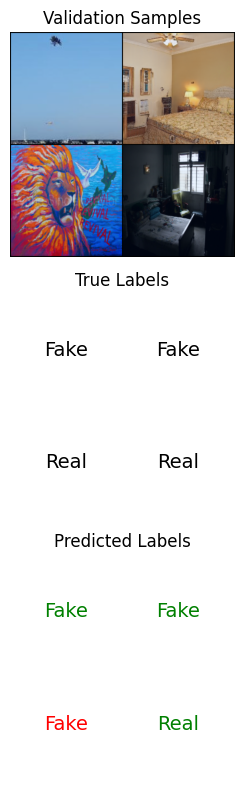

Epoch 2/5 Loss: 0.1776 | Train Acc: 92.86% | Val Acc: 92.06%

🔹 Epoch 3/5


Training: 100%|██████████| 1800/1800 [07:40<00:00,  3.91batch/s, Loss=0.1261, Train Acc=95.10%]


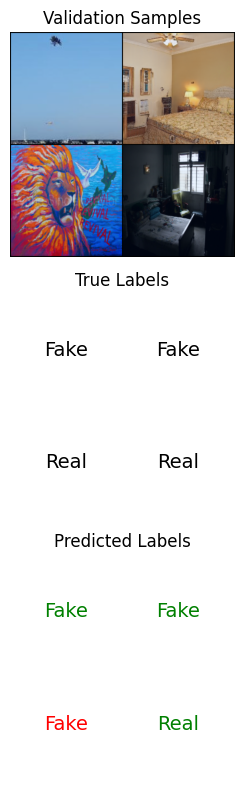

Epoch 3/5 Loss: 0.1261 | Train Acc: 95.10% | Val Acc: 93.61%

🔹 Epoch 4/5


Training: 100%|██████████| 1800/1800 [07:38<00:00,  3.93batch/s, Loss=0.0903, Train Acc=96.56%]


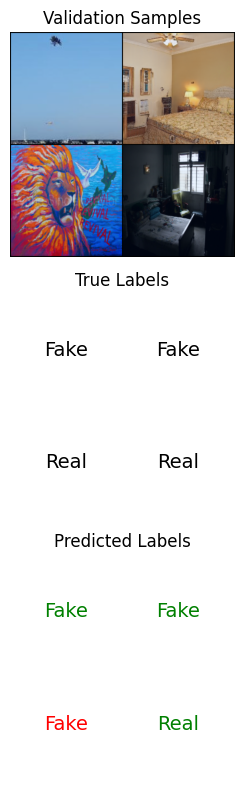

Epoch 4/5 Loss: 0.0903 | Train Acc: 96.56% | Val Acc: 92.67%

🔹 Epoch 5/5


Training: 100%|██████████| 1800/1800 [09:06<00:00,  3.30batch/s, Loss=0.0654, Train Acc=97.54%]


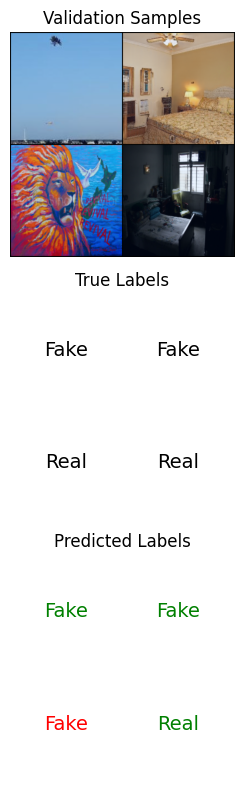

Epoch 5/5 Loss: 0.0654 | Train Acc: 97.54% | Val Acc: 93.02%

Training complete in 53.94 minutes.
Best validation accuracy: 93.61%


In [11]:
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs)